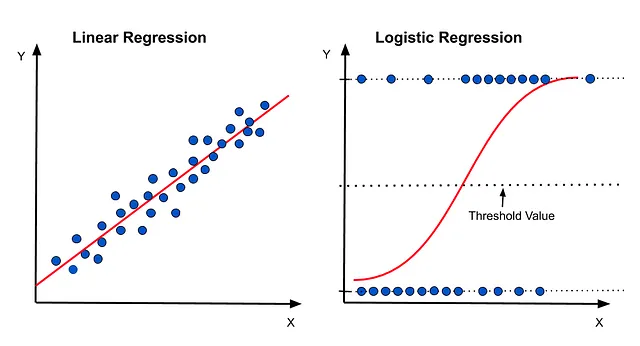

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("heart_disease.csv")
print(df.head())


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   51    0   2       140   308    0        0      142      0      1.5      2   
1   54    1   0       124   266    0        0      109      1      2.2      1   
2   50    0   1       120   244    0        1      162      0      1.1      2   
3   58    1   2       140   211    1        0      165      0      0.0      2   
4   60    1   2       140   185    0        0      155      0      3.0      1   

   ca  thal  target  
0   1     2       1  
1   1     3       0  
2   0     2       1  
3   0     2       1  
4   0     2       0  


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1009 non-null   int64  
 1   sex       1009 non-null   int64  
 2   cp        1009 non-null   int64  
 3   trestbps  1009 non-null   int64  
 4   chol      1009 non-null   int64  
 5   fbs       1009 non-null   int64  
 6   restecg   1009 non-null   int64  
 7   thalach   1009 non-null   int64  
 8   exang     1009 non-null   int64  
 9   oldpeak   1009 non-null   float64
 10  slope     1009 non-null   int64  
 11  ca        1009 non-null   int64  
 12  thal      1009 non-null   int64  
 13  target    1009 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 110.5 KB


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.dropna(inplace=True)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,51,0,2,140,308,0,0,142,0,1.5,2,1,2,1
1,54,1,0,124,266,0,0,109,1,2.2,1,1,3,0
2,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
3,58,1,2,140,211,1,0,165,0,0.0,2,0,2,1
4,60,1,2,140,185,0,0,155,0,3.0,1,0,2,0


In [ ]:
x = df.drop('target',axis=1)

x.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,51,0,2,140,308,0,0,142,0,1.5,2,1,2
1,54,1,0,124,266,0,0,109,1,2.2,1,1,3
2,50,0,1,120,244,0,1,162,0,1.1,2,0,2
3,58,1,2,140,211,1,0,165,0,0.0,2,0,2
4,60,1,2,140,185,0,0,155,0,3.0,1,0,2


In [ ]:
y = df['target']
y.head()

,target
0,1
1,0
2,1
3,1
4,0


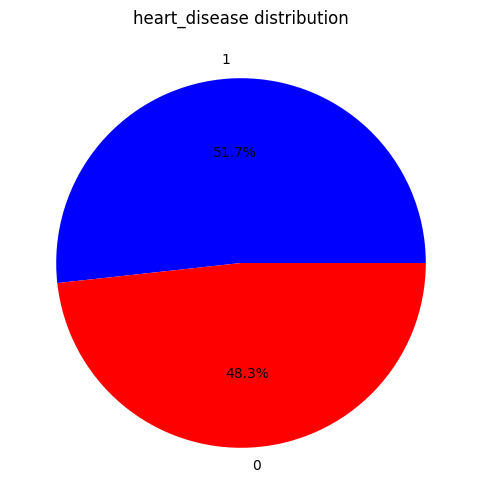

In [ ]:
#pie chart to see the % of heart disease and not having heart disease
plt.figure(figsize=(6,6))
df['target'].value_counts().plot.pie(autopct="%1.1f%%",colors=['blue','red'])
plt.title("heart_disease distribution")
plt.ylabel("")
plt.show()

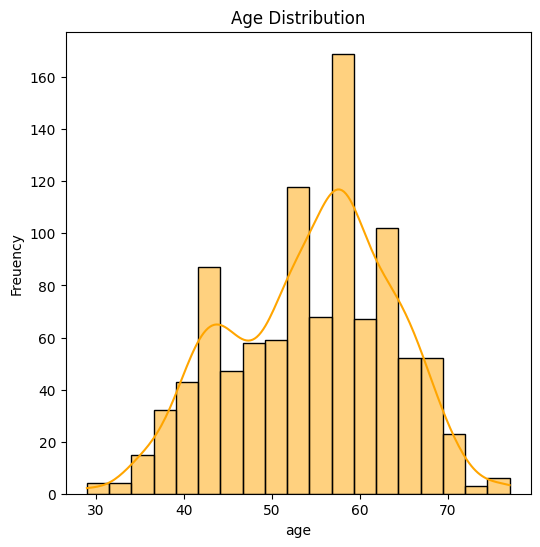

In [ ]:
#%pip install seaborn
import seaborn as sns
plt.figure(figsize=(6,6))
sns.histplot(df['age'],kde=True,color = 'orange')
plt.title('Age Distribution')
plt.xlabel('age')
plt.ylabel('Freuency')
plt.show()

In [ ]:
#logistic regresion model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y , test_size=0.2)

In [ ]:
y_test.head()

,target
569,1
55,0
793,1
612,1
375,0


In [ ]:
x_test.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
569,40,1,3,140,199,0,1,178,1,1.4,2,0,3
55,61,1,0,140,207,0,0,138,1,1.9,2,1,3
793,54,0,2,110,214,0,1,158,0,1.6,1,0,2
612,69,0,3,140,239,0,1,151,0,1.8,2,2,2
375,45,1,3,110,264,0,1,132,0,1.2,1,0,3


In [ ]:
scaler  = StandardScaler()
x_train_scaler = scaler.fit_transform(x_train)
x_test_scalert = scaler.transform(x_test)


x_test_scalert


array([[-1.64539264,  0.66413209,  2.00536061, ...,  0.9851237 ,
        -0.73865584,  1.10491911],
       [ 0.70514846,  0.66413209, -0.91580548, ...,  0.9851237 ,
         0.22903128,  1.10491911],
       [-0.07836524, -1.50572457,  1.03163858, ..., -0.62417757,
        -0.73865584, -0.52817562],
       ...,
       [ 0.25742635,  0.66413209,  1.03163858, ..., -0.62417757,
         0.22903128,  1.10491911],
       [-0.52608735, -1.50572457,  0.05791655, ...,  0.9851237 ,
        -0.73865584, -0.52817562],
       [ 0.92900952, -1.50572457, -0.91580548, ..., -0.62417757,
         1.19671839, -0.52817562]])

In [ ]:
log_regrestion = LogisticRegression()

log_regrestion.fit(x_train_scaler,y_train)
# .pkl

LogisticRegression()

In [ ]:
import pickle
with open('log_reg.pkl',mode='wb') as s:
    pickle.dump(log_regrestion,s)

In [ ]:
with open('scaler.pkl',mode='wb') as f:
    pickle.dump(scaler,f)

In [ ]:
print(x_test.head())
print(y_test.head())

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
569   40    1   3       140   199    0        1      178      1      1.4   
55    61    1   0       140   207    0        0      138      1      1.9   
793   54    0   2       110   214    0        1      158      0      1.6   
612   69    0   3       140   239    0        1      151      0      1.8   
375   45    1   3       110   264    0        1      132      0      1.2   

     slope  ca  thal  
569      2   0     3  
55       2   1     3  
793      1   0     2  
612      2   2     2  
375      1   0     3  
569    1
55     0
793    1
612    1
375    0
Name: target, dtype: int64


In [ ]:
test_arr = np.array(x_test)
print(test_arr)

[[40.  1.  3. ...  2.  0.  3.]
 [61.  1.  0. ...  2.  1.  3.]
 [54.  0.  2. ...  1.  0.  2.]
 ...
 [57.  1.  2. ...  1.  1.  3.]
 [50.  0.  1. ...  2.  0.  2.]
 [63.  0.  0. ...  1.  2.  2.]]


In [ ]:
test_scaler = scaler.transform(test_arr)
# Create 10 sample test cases
sample_cases = np.array([
    # [age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal]
        [67, 1, 4, 120, 229, 0, 2, 129, 1, 2.6, 2, 2, 7],
        [57, 1, 2, 124, 261, 0, 0, 141, 0, 0.3, 1, 0, 7],
        [64, 1, 4, 128, 263, 0, 0, 105, 1, 0.2, 2, 1, 7],
        [59, 1, 4, 135, 234, 0, 0, 161, 0, 0.5, 2, 0, 7],
        [46, 1, 4, 140, 311, 0, 0, 120, 1, 1.8, 2, 2, 7],
        [71, 0, 4, 112, 149, 0, 0, 125, 0, 1.6, 2, 0, 3],
        [60, 1, 4, 140, 293, 0, 2, 170, 0, 1.2, 2, 2, 7],
        [48, 0, 3, 130, 275, 0, 0, 139, 0, 0.2, 1, 0, 3],
        [40, 1, 1, 140, 199, 0, 0, 178, 1, 1.4, 1, 0, 7],
        [54, 0, 2, 132, 288, 1, 2, 159, 1, 0, 1, 1, 3]
])
rand_cas = scaler.transform(sample_cases)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
with open("log_reg.pkl",mode='rb') as f:
    logreg_model = pickle.load(f)
with open("scaler.pkl",mode='rb') as f:
    scal_model = pickle.load(f)

In [ ]:
predict_logreg = logreg_model.predict(test_scaler)
sample_predict_logreg = logreg_model.predict(rand_cas)
# print(x_test.head())
print(predict_logreg)
print(sample_predict_logreg)

[1 0 1 1 1 1 0 1 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 0 1 1 1 1 0
 1 1 0 0 1 1 0 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0
 1 0 1 1 1 0 0 0 1 1 1 1 1 0 0 0 0 1 1 0 0 1 0 1 1 1 0 1 0 0 0 1 0 0 0 1 0
 1 1 1 1 1 0 0 1 1 0 1 0 1 0 0 1 0 1 0 0 0 1 1 1 1 0 1 0 1 1 0 1 1 1 0 1 1
 1 1 0 0 1 1 0 1 0 0 0 1 0 1 1 1 1 1 0 0 1 0 1 1 1 0 1 1 0 0 0 1 0 0 1 1 1
 1 0 0 1 1 1 1 0 0 0 1 1 1 0 1 1 0]
[0 0 0 0 0 1 0 1 0 1]


In [ ]:
acc_logreg = accuracy_score(y_test,predict_logreg)
print(acc_logreg)

0.8663366336633663


In [ ]:
calssificationreport = classification_report(y_test,predict_logreg)
print(calssificationreport)
#0 no heart disease
#1 heart disease

              precision    recall  f1-score   support

           0       0.91      0.81      0.85        98
           1       0.83      0.92      0.88       104

    accuracy                           0.87       202
   macro avg       0.87      0.86      0.87       202
weighted avg       0.87      0.87      0.87       202



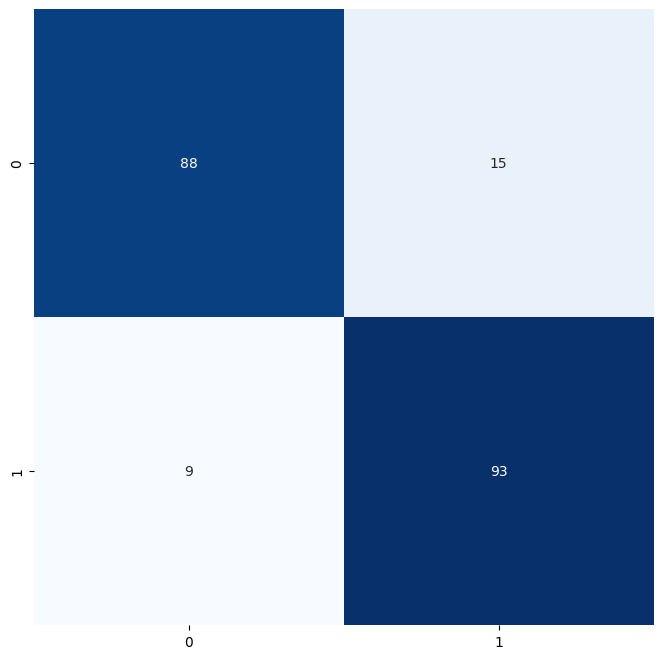

In [ ]:
plt.figure(figsize=(8,8))
cm  = confusion_matrix(y_test,predict_logreg)
sns.heatmap(cm,annot=True,cmap='Blues',cbar=False)
plt.show()